# TFR — your working notebook

You work **here**, in Jupyter — the way you always have.

The files in `src/` are just a **library you import**, like `numpy` or `astropy`. You never write inside them. You only open one to *read* a function when you want to know what it does.

Everything below is **yours**: you call the tools, look at the results, make the plots.

## 1. Setup + imports (all at the top)

In [1]:
import sys, os, pathlib
# find the repo root (the folder that contains src/) and work from there,
# so imports and config paths resolve no matter where Jupyter was started
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'src').is_dir())
os.chdir(ROOT); sys.path.insert(0, str(ROOT / 'src'))
print('working from', ROOT)

import numpy as np
import matplotlib.pyplot as plt

from galaxy_sidm.io import load_config
from galaxy_sidm.mock.tables import assemble   # <- a tool from src/, you just call it

working from /leonardo/home/userexternal/acosta01/master_thesis_project


## 2. Load the disc table

`assemble()` does the boring work (reads the MORDOR samples + BBarolo rings, applies the disc cuts) and hands back one row per usable disc. You don't need to know *how* it does that to use it — but you can open `src/galaxy_sidm/mock/tables.py` and read it whenever you're curious.

In [2]:
cfg  = load_config(None)
rows = assemble(cfg)              # a list of dicts, one per usable disc
print(len(rows), 'usable discs')
rows[0]                          # look at one row — what fields do we get?

4046 usable discs


{'model': 'CDM',
 'snap': 17,
 'z': 5.0,
 'sub_id': 1202,
 'Mstar': 18771900000.0,
 'M200c': 804934254592.0,
 'M_neutral': 30289410598.068424,
 'v_flat': 222.004,
 'IsDisc': 1,
 'bbarolo_rc': 0}

In [4]:
rows[1]

{'model': 'CDM',
 'snap': 21,
 'z': 4.0,
 'sub_id': 668,
 'Mstar': 73428900000.0,
 'M200c': 2883970924544.0,
 'M_neutral': 62227877220.46156,
 'v_flat': 130.31766666666667,
 'IsDisc': 1,
 'bbarolo_rc': 0}

## 3. The part that's YOURS — explore & plot

This is the story you're telling. Write it however you like; change it, break it, redo it. Nothing here is precious.

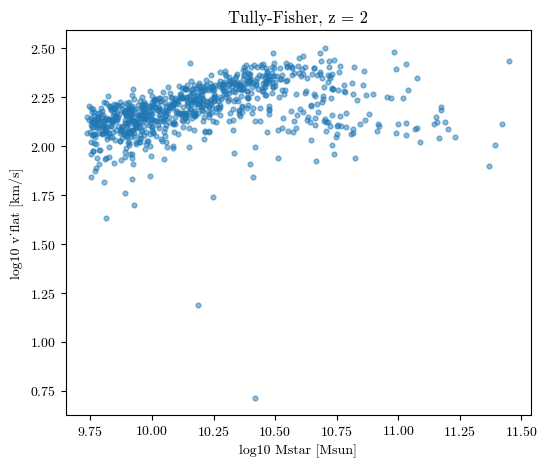

In [3]:
z2 = [r for r in rows if r['z'] == 2 and r['v_flat'] > 0 and r['Mstar'] > 0]
logM = np.log10([r['Mstar']  for r in z2])
logV = np.log10([r['v_flat'] for r in z2])

plt.figure(figsize=(6, 5))
plt.scatter(logM, logV, s=12, alpha=0.5)
plt.xlabel('log10 Mstar [Msun]')
plt.ylabel('log10 v_flat [km/s]')
plt.title('Tully-Fisher, z = 2')
plt.show()